# Dataset

This project uses the RUHSOLD dataset for fine-grained Roman Urdu hate speech detection.

Files used throughout the project:

- RUHSOLD_train.tsv (6408 samples)
- RUHSOLD_validation.tsv (801 samples)
- RUHSOLD_test.tsv (2003 samples)

Note:
The original RUHSOLD repository contains a duplicated validation file. Therefore, a new validation set was created by performing a stratified split on the original training set while keeping the official test set unchanged. During verification, seven duplicate tweets were found between the official training and test sets. Since these duplicates originate from the released dataset and account for less than 0.1% of all samples, they were retained to preserve comparability with prior work.

In [1]:
import pandas as pd

train_df = pd.read_csv("RUHSOLD_train.tsv", sep="\t", header=None)
val_df   = pd.read_csv("RUHSOLD_validation.tsv", sep="\t", header=None)
test_df  = pd.read_csv("RUHSOLD_test.tsv", sep="\t", header=None)

train_df.columns = ["tweet", "label"]
val_df.columns   = ["tweet", "label"]
test_df.columns  = ["tweet", "label"]

In [2]:
# ============================================================
# 3. Dataset Overview
# ============================================================

# Display the number of samples in each split

print("=" * 60)
print("RUHSOLD Dataset Summary")
print("=" * 60)

print(f"Training samples   : {len(train_df)}")
print(f"Validation samples : {len(val_df)}")
print(f"Test samples       : {len(test_df)}")

print("\nTraining Set Preview")

train_df.head()

RUHSOLD Dataset Summary
Training samples   : 6408
Validation samples : 801
Test samples       : 2003

Training Set Preview


,tweet,label
0,kia howa hai aap ko allah bless and protect yo...,1
1,randdi hai,3
2,smjh to agai thi mjhy,1
3,haan yrr tuny sahi thukayi ki abhi tak lund da...,3
4,rundi ka bacha bharwaaa ptm ka kuttaa,0


In [3]:
# ============================================================
# 4. Data Quality Analysis
# ============================================================

# Check for missing values

print("=" * 60)
print("Missing Values")
print("=" * 60)

print(f"Training Tweets Missing : {train_df['tweet'].isnull().sum()}")
print(f"Training Labels Missing : {train_df['label'].isnull().sum()}")

print(f"\nValidation Tweets Missing : {val_df['tweet'].isnull().sum()}")
print(f"Validation Labels Missing : {val_df['label'].isnull().sum()}")

print(f"\nTest Tweets Missing : {test_df['tweet'].isnull().sum()}")
print(f"Test Labels Missing : {test_df['label'].isnull().sum()}")

Missing Values
Training Tweets Missing : 0
Training Labels Missing : 0

Validation Tweets Missing : 0
Validation Labels Missing : 0

Test Tweets Missing : 0
Test Labels Missing : 0


In [4]:
# Mapping from numerical labels to class names

label_names = {
    0: "Abusive/Offensive",
    1: "Normal",
    2: "Religious Hate",
    3: "Sexism",
    4: "Profane"
}

In [5]:
# Count the number of samples in each class

class_counts = train_df["label"].value_counts().sort_index()

print(class_counts)

label
0    1537
1    3423
2     500
3     537
4     411
Name: count, dtype: int64


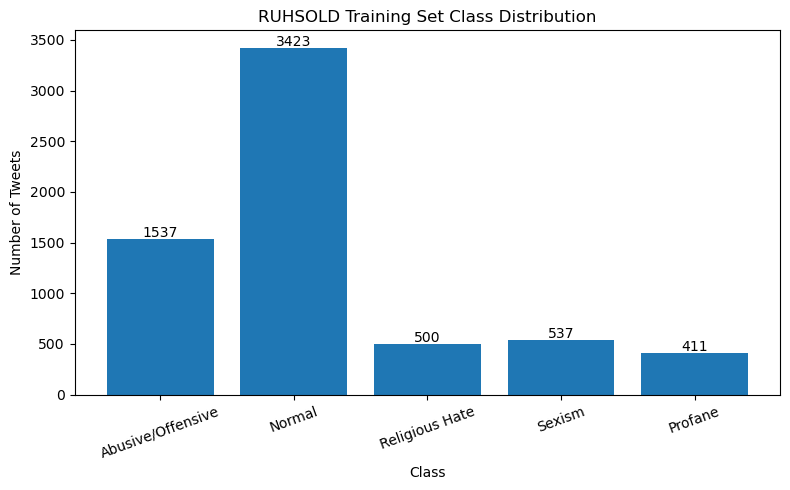

In [6]:
import matplotlib.pyplot as plt

# ============================================================
# Plot Class Distribution
# ============================================================

plt.figure(figsize=(8,5))

bars = plt.bar(
    [label_names[i] for i in class_counts.index],
    class_counts.values
)

plt.title("RUHSOLD Training Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Tweets")

plt.xticks(rotation=20)

# Display values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 20,
        f"{int(height)}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# Percentage Distribution
# ============================================================

class_percentages = (
    train_df["label"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print("Percentage Distribution\n")

for label, percentage in class_percentages.items():
    print(f"{label_names[label]:<22}: {percentage:.2f}%")

Percentage Distribution

Abusive/Offensive     : 23.99%
Normal                : 53.42%
Religious Hate        : 7.80%
Sexism                : 8.38%
Profane               : 6.41%


In [8]:
# ============================================================
# Class Imbalance Ratio
# ============================================================

largest_class = class_counts.max()
smallest_class = class_counts.min()

imbalance_ratio = largest_class / smallest_class

print(f"Largest Class : {largest_class}")
print(f"Smallest Class: {smallest_class}")
print(f"Imbalance Ratio: {imbalance_ratio:.2f}")

Largest Class : 3423
Smallest Class: 411
Imbalance Ratio: 8.33


In [9]:
# ============================================================
# Samples Needed to Match the Majority Class
# ============================================================

majority_count = class_counts.max()

print("=" * 60)
print("Additional Samples Needed for Class Balancing")
print("=" * 60)

for label in class_counts.index:
    needed = majority_count - class_counts[label]
    print(f"{label_names[label]:<22}: {needed}")

Additional Samples Needed for Class Balancing
Abusive/Offensive     : 1886
Normal                : 0
Religious Hate        : 2923
Sexism                : 2886
Profane               : 3012


### Observations

- The Normal class accounts for over half of the training data.
- The Profane class is the smallest category.
- The largest class contains approximately 8.3 times more samples than the smallest class.
- This class imbalance is expected to bias a classifier toward majority classes, motivating the use of LLM-based augmentation to improve minority-class representation.

# Tweet length analysis

In [10]:
# ============================================================
# 6. Tweet Length Analysis
# ============================================================

# Calculate the number of words in each tweet

train_df["tweet_length"] = train_df["tweet"].apply(
    lambda x: len(str(x).split())
)

# Display the first few rows

train_df[["tweet", "tweet_length"]].head()

,tweet,tweet_length
0,kia howa hai aap ko allah bless and protect yo...,11
1,randdi hai,2
2,smjh to agai thi mjhy,5
3,haan yrr tuny sahi thukayi ki abhi tak lund da...,41
4,rundi ka bacha bharwaaa ptm ka kuttaa,7


In [11]:
# ============================================================
# Overall Tweet Length Statistics
# ============================================================

print("=" * 60)
print("Overall Tweet Length Statistics")
print("=" * 60)

print(train_df["tweet_length"].describe())

Overall Tweet Length Statistics
count    6408.000000
mean       17.079432
std        12.511363
min         1.000000
25%         8.000000
50%        13.000000
75%        22.000000
max        71.000000
Name: tweet_length, dtype: float64


In [12]:
# ============================================================
# Tweet Length Statistics by Class
# ============================================================

length_stats = (
    train_df
    .groupby("label")["tweet_length"]
    .describe()
)

length_stats.index = [
    label_names[i] for i in length_stats.index
]

length_stats

,count,mean,std,min,25%,50%,75%,max
Abusive/Offensive,1537.0,18.450228,13.310750,1.0,8.0,15.0,25.0,65.0
Normal,3423.0,15.994741,11.827465,1.0,8.0,12.0,20.0,71.0
Religious Hate,500.0,22.044000,14.495181,2.0,11.0,19.0,31.0,62.0
Sexism,537.0,16.677840,12.154729,2.0,8.0,13.0,23.0,60.0
Profane,411.0,15.472019,10.780790,2.0,8.0,13.0,19.0,61.0


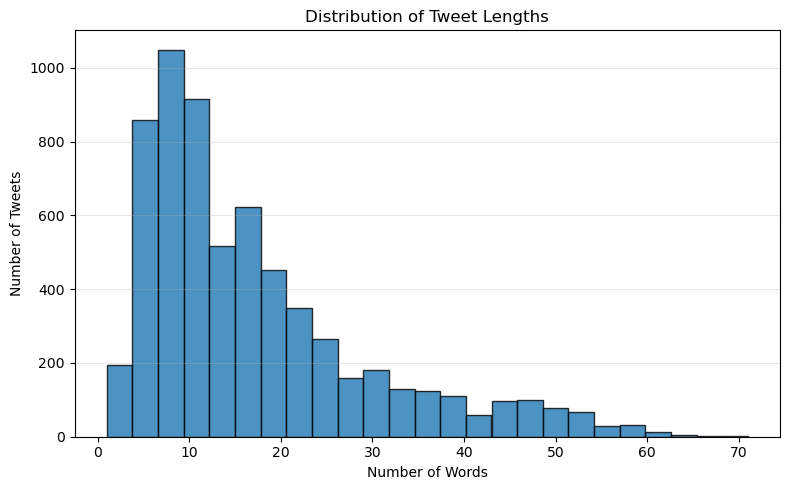

In [17]:
# ============================================================
# Distribution of Tweet Lengths
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    train_df["tweet_length"],
    bins=25,
    edgecolor="black",
    alpha=0.8
)

plt.grid(axis="y", alpha=0.3)
plt.title("Distribution of Tweet Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Number of Tweets")

plt.tight_layout()
plt.show()

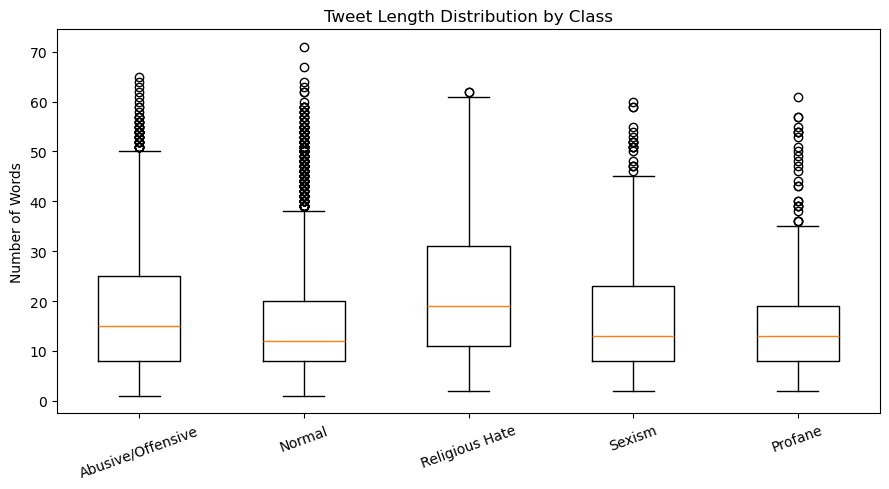

In [14]:
# ============================================================
# Tweet Length by Class
# ============================================================

plt.figure(figsize=(9,5))

data = [
    train_df[train_df["label"] == i]["tweet_length"]
    for i in range(5)
]

plt.boxplot(
    data,
    tick_labels=list(label_names.values()),
    showfliers=True
)

plt.title("Tweet Length Distribution by Class")
plt.ylabel("Number of Words")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# Five Longest Tweets
# ============================================================

train_df.sort_values(
    by="tweet_length",
    ascending=False
)[["tweet","label","tweet_length"]].head()

,tweet,label,tweet_length
6346,yr kr rhi hon gi no doubt... par na m ne kbhi...,1,71
5572,afghans ko hi train kia tha ya jo kuch hmdard ...,1,67
1119,tujh jese bharwe ki itni c bat smjhne ki bhi a...,0,65
4546,"kia haal kr diya es beghairt pm ny, kha hum as...",0,64
1098,ye e mane kaha .. or jo socha tha wo hua nai k...,1,64


In [16]:
# ============================================================
# Five Shortest Tweets
# ============================================================

train_df.sort_values(
    by="tweet_length"
)[["tweet","label","tweet_length"]].head()

,tweet,label,tweet_length
4851,wahh🔥🔥,1,1
2683,bharwe😂😂😂,0,1
3222,hahahaha,1,1
4224,lanati😡,0,1
6024,akhrot*,0,1


# Vocabulary Analysis

In [18]:
# ============================================================
# Vocabulary Analysis
# ============================================================

from collections import Counter
import re

In [19]:
# ============================================================
# Function to clean text for vocabulary analysis
# ============================================================

def clean_text(text):

    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove mentions
    text = re.sub(r"@\w+", "", text)

    # Remove hashtags symbol only
    text = text.replace("#", "")

    # Remove punctuation
    text = re.sub(r"[^\w\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [20]:
# ============================================================
# Overall Most Frequent Words
# ============================================================

all_words = []

for tweet in train_df["tweet"]:

    cleaned = clean_text(tweet)

    all_words.extend(cleaned.split())

word_counts = Counter(all_words)

word_counts.most_common(30)

[('hai', 2085),
 ('ki', 1608),
 ('k', 1469),
 ('ko', 1340),
 ('to', 1212),
 ('ka', 1070),
 ('ho', 908),
 ('se', 817),
 ('ye', 708),
 ('na', 702),
 ('ha', 664),
 ('bhi', 629),
 ('hain', 612),
 ('is', 583),
 ('tu', 579),
 ('nahi', 578),
 ('ke', 564),
 ('or', 553),
 ('me', 553),
 ('aur', 544),
 ('hi', 520),
 ('kar', 464),
 ('koi', 455),
 ('nhi', 452),
 ('h', 442),
 ('b', 434),
 ('tha', 431),
 ('he', 420),
 ('main', 413),
 ('jo', 409)]

In [25]:
# ==========================================================
# Roman Urdu Stopword List
# (Minimal list for Exploratory Data Analysis only)
# ==========================================================

roman_stopwords = {

    # Pronouns
    "mai", "main", "me", "mein", "mera", "meri", "mere",
    "hum", "ham", "hamara", "hamari", "hamare",
    "tum", "tumhara", "tumhari", "tumhare",
    "tu", "tera", "teri", "tere",
    "ap", "aap", "apka", "apki", "apke",
    "ye", "yeh", "wo", "woh",
    "is", "iss", "us", "uss",

    # Common verbs
    "hai", "ha", "h",
    "hain",
    "ho", "hon",
    "he", "hy",
    "tha", "thi", "thay", "the",

    # Negation
    "nahi", "nhi", "nai", "nahi",

    # Common connectors
    "or", "aur", "lekin", "magar",
    "agar", "to", "toh",
    "bhi", "hi",
    "phir",
    "sirf",

    # Question words
    "kya", "kya",

    # Prepositions
    "ki", "ka", "ke",
    "ko", "se",
    "par", "per",
    "tak",

    # Miscellaneous common words
    "kar", "kr",
    "jo",
    "jab",
    "ab",
    "abhi",
    "fir",
    "phr",
    "koi",
    "kuch",
    "sab",
    "log",
    "liye",
    "baat",
    "raha",
    "rahi",
    "rahe",
    "hota",
    "hoti",
    "hote",
    "kia",

    # English fillers commonly mixed in Roman Urdu
    "and",
    "the",
    "for",
    "of",
    "in",
    "on",
    "is",
    "are",
    "was",
    "were",
    "be",
    "you",
    "your"
}

In [26]:
filtered_words = [
    word
    for word in all_words
    if word not in roman_stopwords and len(word) > 2
]

filtered_counts = Counter(filtered_words)

filtered_counts.most_common(30)

[('randi', 384),
 ('bhenchod', 330),
 ('maa', 318),
 ('bhai', 241),
 ('pakistan', 238),
 ('baap', 233),
 ('apni', 231),
 ('kisi', 227),
 ('yahoodi', 208),
 ('pata', 195),
 ('allah', 179),
 ('aurat', 178),
 ('say', 168),
 ('yahodi', 163),
 ('chod', 157),
 ('hijra', 155),
 ('kiya', 154),
 ('sath', 152),
 ('khud', 146),
 ('hoga', 141),
 ('akhrot', 137),
 ('bharwe', 137),
 ('mat', 136),
 ('khan', 134),
 ('dekh', 131),
 ('kon', 131),
 ('bhen', 130),
 ('but', 130),
 ('bat', 130),
 ('imran', 128)]

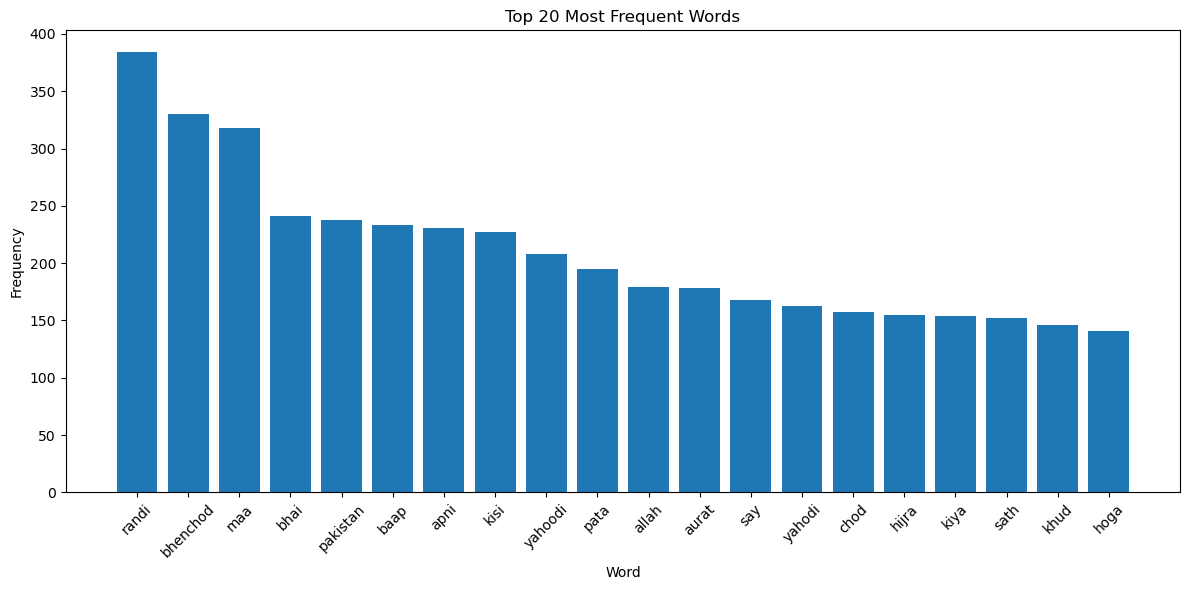

In [27]:
import matplotlib.pyplot as plt

top_words = filtered_counts.most_common(20)

words = [w for w,c in top_words]
counts = [c for w,c in top_words]

plt.figure(figsize=(12,6))

plt.bar(words,counts)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Word")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [28]:
# ============================================================
# Most Frequent Words for Each Class
# ============================================================

for label in sorted(train_df["label"].unique()):

    words = []

    class_df = train_df[train_df["label"] == label]

    for tweet in class_df["tweet"]:

        cleaned = clean_text(tweet)

        words.extend(cleaned.split())

    words = [
        w for w in words
        if w not in roman_stopwords and len(w) > 2
    ]

    counter = Counter(words)

    print("="*70)
    print(label_names[label])
    print("="*70)

    print(counter.most_common(20))

Abusive/Offensive
[('maa', 202), ('baap', 145), ('bhenchod', 138), ('randi', 128), ('bharwe', 125), ('chod', 113), ('bhaunk', 88), ('bhen', 84), ('apni', 83), ('pakistan', 61), ('charsi', 58), ('kisi', 56), ('apne', 54), ('akhrot', 53), ('rundi', 52), ('abe', 46), ('bhai', 46), ('hay', 45), ('nasal', 43), ('mat', 41)]
Normal
[('bhai', 161), ('allah', 132), ('kisi', 128), ('pata', 121), ('say', 96), ('sath', 95), ('din', 90), ('pakistan', 90), ('yahoodi', 89), ('aurat', 88), ('kon', 85), ('mat', 84), ('but', 83), ('akhrot', 81), ('hoga', 81), ('bat', 80), ('that', 79), ('not', 79), ('dekh', 78), ('kiya', 78)]
Religious Hate
[('yahodi', 115), ('yahoodi', 111), ('halala', 81), ('imran', 66), ('pakistan', 61), ('agent', 44), ('harami', 42), ('apni', 42), ('allah', 33), ('hindu', 31), ('maa', 31), ('chore', 30), ('khan', 27), ('bajwa', 26), ('kashmir', 25), ('randi', 25), ('say', 24), ('zakat', 23), ('muslim', 22), ('islam', 21)]
Sexism
[('randi', 193), ('hijra', 131), ('aurat', 43), ('gash

# Character Length Analysis

Unlike the previous section (which counted words), this section measures the number of characters in each tweet.

This helps us answer:

How long are tweets in terms of raw text?
Are some classes much longer than others?
Should synthetic tweets have similar character lengths?

In [29]:
# ============================================================
# 8. Character Length Analysis
# ============================================================

# Calculate the number of characters in each tweet

train_df["char_length"] = train_df["tweet"].astype(str).apply(len)

# Preview

train_df[["tweet", "char_length"]].head()

,tweet,char_length
0,kia howa hai aap ko allah bless and protect yo...,55
1,randdi hai,10
2,smjh to agai thi mjhy,22
3,haan yrr tuny sahi thukayi ki abhi tak lund da...,196
4,rundi ka bacha bharwaaa ptm ka kuttaa,37


In [30]:
# ============================================================
# Overall Character Length Statistics
# ============================================================

print("=" * 60)
print("Overall Character Length Statistics")
print("=" * 60)

print(train_df["char_length"].describe())

Overall Character Length Statistics
count    6408.000000
mean       86.272784
std        65.336178
min         6.000000
25%        39.000000
50%        65.000000
75%       112.250000
max       323.000000
Name: char_length, dtype: float64


In [31]:
# ============================================================
# Character Length Statistics by Class
# ============================================================

char_stats = (
    train_df
    .groupby("label")["char_length"]
    .describe()
)

char_stats.index = [label_names[i] for i in char_stats.index]

char_stats

,count,mean,std,min,25%,50%,75%,max
Abusive/Offensive,1537.0,94.204294,68.333577,6.0,42.0,73.0,129.00,306.0
Normal,3423.0,79.742623,62.568752,7.0,37.0,59.0,98.00,285.0
Religious Hate,500.0,116.124000,75.141047,14.0,56.0,97.0,162.25,323.0
Sexism,537.0,83.629423,61.688391,8.0,38.0,65.0,116.00,280.0
Profane,411.0,78.136253,54.213678,9.0,40.0,65.0,97.00,280.0


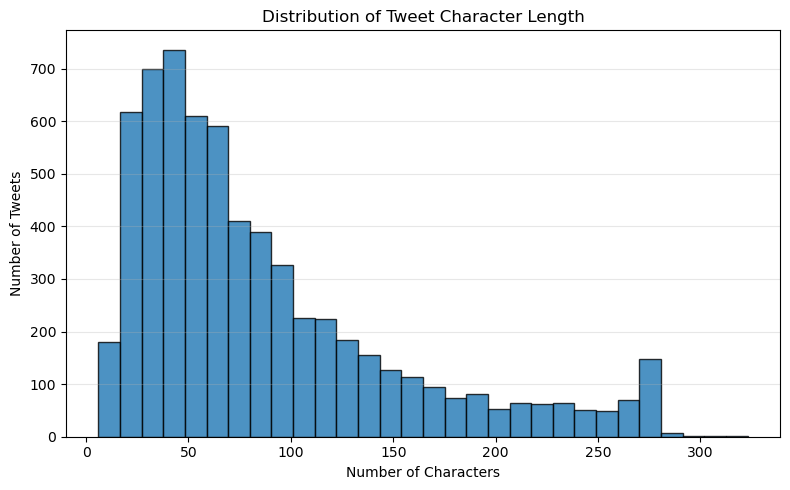

In [32]:
# ============================================================
# Character Length Distribution
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    train_df["char_length"],
    bins=30,
    edgecolor="black",
    alpha=0.8
)

plt.title("Distribution of Tweet Character Length")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Tweets")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [33]:
# ============================================================
# Longest Tweet
# ============================================================

longest = train_df.loc[train_df["char_length"].idxmax()]

print("Longest Tweet")
print("-"*80)
print(longest["tweet"])
print("-"*80)
print(f"Characters: {longest['char_length']}")
print(f"Words: {longest['tweet_length']}")
print(f"Class: {label_names[longest['label']]}")

Longest Tweet
--------------------------------------------------------------------------------
esko bayghart kashmir frosh gandu lanti sazishi bayghart kanjar imran yahodi nay he btaya tha k nawaz sharif bemar ha ab tu apni niki baji paish kar q k tery najaiz abbey nay bola ha 😅😅😅 😅 😅,abusive/offensive,51197244043681554434,1197244043681554434,asimrafi9, mahan bayghart kanjar kashmir frosh lanti sazishi imran yahodi
--------------------------------------------------------------------------------
Characters: 323
Words: 47
Class: Religious Hate


In [34]:
# ============================================================
# Shortest Tweet
# ============================================================

shortest = train_df.loc[train_df["char_length"].idxmin()]

print("Shortest Tweet")
print("-"*80)
print(shortest["tweet"])
print("-"*80)
print(f"Characters: {shortest['char_length']}")
print(f"Words: {shortest['tweet_length']}")
print(f"Class: {label_names[shortest['label']]}")

Shortest Tweet
--------------------------------------------------------------------------------
hat bc
--------------------------------------------------------------------------------
Characters: 6
Words: 2
Class: Abusive/Offensive


In [35]:
# Show tweets containing many commas (possible metadata)

train_df[train_df["tweet"].str.count(",") >= 3][["tweet", "label"]].head(10)

,tweet,label
46,"insaniyat ko bache rahne do, jis mazhab me j...",2
83,"rt : 😎🇵🇰😎 da'awat, walima ya khatam-e-quran p...",0
109,"tm saali kuch bhi bol lo kuch bhi kr lo,karogi...",0
122,"badam, pista, akhrott, chanay, saunf, misri et...",1
156,islam took over many nations since its incepti...,1
189,yar meri koshish hai. inshallah dekhon gi. mer...,1
195,bhenchod apni lums ki team ka coach hi rakh la...,4
215,"sham hote hi ye dil udas hota hai, tute khwabo...",0
220,hope they could have stand against triple tala...,1
409,"path of cruelty , path of violence, path of ha...",2


# code mixing analysis

In [36]:
pip install wordfreq

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 MB 91.5 MB/s  0:00:006m0:00:0100:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [wordfreq]3/4 [wordfreq]
Note: you may need to restart the kernel to use updated packages.


In [37]:
# ==========================================================
# CODE-MIXING ANALYSIS
# ==========================================================

import re
from wordfreq import zipf_frequency

In [38]:
def is_english(word):
    """
    Returns True if a word is recognised as an English word.
    """
    
    word = word.lower()

    # Ignore numbers
    if word.isdigit():
        return False

    # Ignore very short words
    if len(word) <= 2:
        return False

    return zipf_frequency(word, "en") > 3

In [39]:
all_words = []

for tweet in train_df["tweet"]:
    words = re.findall(r"\b[a-zA-Z]+\b", tweet)
    all_words.extend(words)

In [40]:
english_words = [w for w in all_words if is_english(w)]

In [41]:
print("="*60)
print("CODE-MIXING STATISTICS")
print("="*60)

print(f"Total words       : {len(all_words)}")
print(f"English words     : {len(english_words)}")

percentage = 100 * len(english_words) / len(all_words)

print(f"English Percentage: {percentage:.2f}%")

CODE-MIXING STATISTICS
Total words       : 107659
English words     : 30708
English Percentage: 28.52%


In [42]:
from collections import Counter

english_counter = Counter([w.lower() for w in english_words])

print("\nTop 30 English Words\n")

for word, count in english_counter.most_common(30):
    print(f"{word:<15} {count}")


Top 30 English Words

hai             2086
kar             464
koi             455
tha             431
main            413
the             385
and             361
tum             334
aap             310
mein            295
kia             255
bhai            241
pakistan        238
you             237
thi             232
log             182
allah           179
yeh             177
say             168
par             167
hum             163
are             159
for             153
mai             150
per             142
mat             136
khan            134
but             130
bat             130
imran           128


In [43]:
label_names = {
    0: "Abusive/Offensive",
    1: "Normal",
    2: "Religious Hate",
    3: "Sexism",
    4: "Profane"
}

print("="*70)
print("CODE-MIXING PER CLASS")
print("="*70)

for label in sorted(train_df["label"].unique()):

    subset = train_df[train_df["label"] == label]

    total = 0
    english = 0

    for tweet in subset["tweet"]:

        words = re.findall(r"\b[a-zA-Z]+\b", tweet)

        total += len(words)

        english += sum(is_english(w) for w in words)

    percent = 100 * english / total

    print(f"{label_names[label]:<22} {percent:.2f}%")

CODE-MIXING PER CLASS
Abusive/Offensive      23.53%
Normal                 31.95%
Religious Hate         27.31%
Sexism                 22.98%
Profane                31.57%


In [44]:
!wget https://raw.githubusercontent.com/dwyl/english-words/master/words_alpha.txt

--2026-06-26 17:53:23--  https://raw.githubusercontent.com/dwyl/english-words/master/words_alpha.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4234910 (4.0M) [text/plain]
Saving to: ‘words_alpha.txt’

words_alpha.txt     100%[===================>]   4.04M  --.-KB/s    in 0.01s   

2026-06-26 17:53:24 (294 MB/s) - ‘words_alpha.txt’ saved [4234910/4234910]



In [45]:
# ==========================================================
# Load English Vocabulary
# ==========================================================

with open("words_alpha.txt") as f:
    english_vocab = set(word.strip().lower() for word in f)

print(f"English vocabulary size: {len(english_vocab):,}")

English vocabulary size: 370,105


In [46]:
roman_urdu_words = {
    "hai","hain","tha","thi","the",
    "kar","karo","kia","ki","ka","ke","ko",
    "se","say","par","per",
    "tum","aap","hum","mein","main",
    "mera","meri","mere",
    "tera","teri","tere",
    "ham","ap","apna","apni",
    "koi","nhi","nahi","han","ha",
    "yah","ye","yeh","jo","or","aur",
    "bhai","allah","pakistan","imran",
    "jan","acha","acha","sab","log",
    "raha","rahi","rahe"
}

In [47]:
import re

def is_english(word):

    word = word.lower()

    if len(word) < 3:
        return False

    if word in roman_urdu_words:
        return False

    return word in english_vocab

In [48]:
from collections import Counter

all_words = []
english_words = []

for tweet in train_df["tweet"]:

    words = re.findall(r"\b[a-zA-Z]+\b", tweet)

    all_words.extend(words)

    for w in words:
        if is_english(w):
            english_words.append(w.lower())

print("="*60)
print("UPDATED CODE-MIXING")
print("="*60)

print("Total words:", len(all_words))
print("English words:", len(english_words))
print(f"Percentage: {100*len(english_words)/len(all_words):.2f}%")

UPDATED CODE-MIXING
Total words: 107659
English words: 28142
Percentage: 26.14%


In [49]:
counter = Counter(english_words)

print("\nTop English Words\n")

for word,count in counter.most_common(30):
    print(f"{word:<15}{count}")


Top English Words

and            361
you            237
pata           195
are            159
hijra          155
for            153
khud           146
hoga           141
akhrot         137
mat            136
khan           134
kon            131
but            130
bat            130
din            128
rha            126
that           126
this           120
jab            118
aik            114
halala         111
not            110
tou            102
they           100
hay            98
hoti           96
pta            95
dil            94
sir            93
like           93


In [50]:
print("="*70)
print("UPDATED CODE-MIXING PER CLASS")
print("="*70)

for label in sorted(train_df["label"].unique()):

    subset = train_df[train_df["label"] == label]

    total = 0
    english = 0

    for tweet in subset["tweet"]:

        words = re.findall(r"\b[a-zA-Z]+\b", tweet)

        total += len(words)

        english += sum(is_english(w) for w in words)

    print(f"{label_names[label]:<22} {100*english/total:.2f}%")

UPDATED CODE-MIXING PER CLASS
Abusive/Offensive      22.10%
Normal                 28.60%
Religious Hate         25.50%
Sexism                 22.47%
Profane                29.55%


# Emoji, Hashtag, Mention, and URL Analysis

In [51]:
# ==========================================================
# EMOJI, HASHTAG, MENTION & URL ANALYSIS
# ==========================================================

import re

# Regular expressions
url_pattern = r"http\S+|www\.\S+"
mention_pattern = r"@\w+"
hashtag_pattern = r"#\w+"

# Emoji pattern
emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # Emoticons
    "\U0001F300-\U0001F5FF"  # Symbols & Pictographs
    "\U0001F680-\U0001F6FF"  # Transport & Map
    "\U0001F700-\U0001F77F"
    "\U0001F780-\U0001F7FF"
    "\U0001F800-\U0001F8FF"
    "\U0001F900-\U0001F9FF"
    "\U0001FA00-\U0001FAFF"
    "\U00002702-\U000027B0"
    "\U000024C2-\U0001F251"
    "]+",
    flags=re.UNICODE
)

In [52]:
total = len(train_df)

emoji_count = 0
hashtag_count = 0
mention_count = 0
url_count = 0

for tweet in train_df["tweet"]:

    if emoji_pattern.search(tweet):
        emoji_count += 1

    if re.search(hashtag_pattern, tweet):
        hashtag_count += 1

    if re.search(mention_pattern, tweet):
        mention_count += 1

    if re.search(url_pattern, tweet):
        url_count += 1

In [53]:
print("="*65)
print("SPECIAL TOKEN ANALYSIS")
print("="*65)

print(f"Total Tweets : {total}")

print(f"\nTweets containing emojis   : {emoji_count} ({emoji_count/total*100:.2f}%)")
print(f"Tweets containing hashtags : {hashtag_count} ({hashtag_count/total*100:.2f}%)")
print(f"Tweets containing mentions : {mention_count} ({mention_count/total*100:.2f}%)")
print(f"Tweets containing URLs     : {url_count} ({url_count/total*100:.2f}%)")

SPECIAL TOKEN ANALYSIS
Total Tweets : 6408

Tweets containing emojis   : 2064 (32.21%)
Tweets containing hashtags : 341 (5.32%)
Tweets containing mentions : 0 (0.00%)
Tweets containing URLs     : 3 (0.05%)


In [54]:
print("="*70)
print("Example Tweets with Emojis")
print("="*70)

emoji_examples = train_df[
    train_df["tweet"].str.contains(emoji_pattern)
]["tweet"].head(5)

for tweet in emoji_examples:
    print("-", tweet)

Example Tweets with Emojis
- haan yrr tuny sahi thukayi ki abhi tak lund dard kr raha hai sahi randi hai...wesy ghalti ki tjhy lund dy k abb pta nhi lund ko koi bemari he naw llag jaye gandi phudi k moun jo lag gayi hai😈😈😈👙🤣🤣
- faasla rakhein ba'ad mein aap interest lose kar jate hain aur hum attachments ki maar marte hain🙊
- tum log pappu mat bano kyunki sonia aur pawar ne tumnlogo ko pappu hi nahi kutta bana kar chhod diya hai..ab kai kai karte rahi; bhaunk toh sakte nahi 🤣🤣
- khowla behen itni explanation dene ki zarurat nai kuch insano ke sar may dimagh ki jaga akhrot hota hai 😁 #achasorry
- aur  ansoo bahany ki bhtreen  jagh sajda ha 🖤🖤


# LEXICAL DIVERSITY ANALYSIS

In [55]:
# ==========================================================
# LEXICAL DIVERSITY ANALYSIS
# ==========================================================

import re
from collections import Counter
import pandas as pd

In [56]:
results = []

for label in sorted(train_df["label"].unique()):

    subset = train_df[train_df["label"] == label]

    all_words = []

    for tweet in subset["tweet"]:

        words = re.findall(r"\b[a-zA-Z]+\b", tweet.lower())

        all_words.extend(words)

    total_words = len(all_words)

    unique_words = len(set(all_words))

    ttr = unique_words / total_words

    results.append([
        label_names[label],
        len(subset),
        total_words,
        unique_words,
        ttr
    ])

In [57]:
lexical_df = pd.DataFrame(
    results,
    columns=[
        "Class",
        "Tweets",
        "Total Words",
        "Unique Words",
        "Type-Token Ratio"
    ]
)

lexical_df["Type-Token Ratio"] = lexical_df["Type-Token Ratio"].round(4)

lexical_df

,Class,Tweets,Total Words,Unique Words,Type-Token Ratio
0,Abusive/Offensive,1537,28073,6943,0.2473
1,Normal,3423,53628,10521,0.1962
2,Religious Hate,500,10976,3524,0.3211
3,Sexism,537,8837,2949,0.3337
4,Profane,411,6145,2404,0.3912


In [58]:
print("="*70)
print("LEXICAL DIVERSITY")
print("="*70)

print(
    lexical_df.sort_values(
        "Type-Token Ratio",
        ascending=False
    )
)

LEXICAL DIVERSITY
               Class  Tweets  Total Words  Unique Words  Type-Token Ratio
4            Profane     411         6145          2404            0.3912
3             Sexism     537         8837          2949            0.3337
2     Religious Hate     500        10976          3524            0.3211
0  Abusive/Offensive    1537        28073          6943            0.2473
1             Normal    3423        53628         10521            0.1962


In [59]:
all_words = []

for tweet in train_df["tweet"]:

    words = re.findall(r"\b[a-zA-Z]+\b", tweet.lower())

    all_words.extend(words)

print("="*60)
print("OVERALL DATASET")
print("="*60)

print("Total words :", len(all_words))
print("Unique words:", len(set(all_words)))
print("TTR:", round(len(set(all_words))/len(all_words),4))

OVERALL DATASET
Total words : 107659
Unique words: 16854
TTR: 0.1565
